# Assignment 4

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:

    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).
---

### Import libraries

In [42]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from keras import metrics
from keras.datasets import fashion_mnist

tf.get_logger().setLevel('INFO')

---
### Step 1: Data ingestion

You'll train a binary classifier using the [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset. This consists of 70,000 grayscale images (28x28). Each image is associated with 1 of 10 classes. The dataset was split by the creators; there are 60,000 training images and 10,000 test images. Note also that Tensorflow includes a growing [library of datasets](https://www.tensorflow.org/datasets/catalog/overview) and makes it easy to load them in numpy arrays.

In [43]:
# Load the Fashion MNIST dataset.
(X_train, Y_train), (X_test, Y_test) = fashion_mnist.load_data()

---
### Step 2: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) and Data Preprocessing are often iterative processes that involve going back and forth to refine and improve the quality of data analysis and preparation. However, the specific order can vary depending on the project's requirements. In some cases, starting with EDA, as you see in this assignment, could be more useful, but there is no rigid rule dictating the sequence in all situations.

### <span style="color:chocolate">Exercise 1:</span> Getting to know your data (5 points)

Complete the following tasks:

1. Print the shapes and types of (X_train, Y_train) and (X_test, Y_test). Interpret the shapes (i.e., what do the numbers represent?). Hint: For types use the <span style="color:chocolate">type()</span> function.
2. Define a list of strings of class names corresponding to each class in (Y_train, Y_test). Call this list label_names. Hint: Refer to the Fashion MNIST documentation.

In [44]:
# YOUR CODE HERE
# 1. shapes
print('X_train shape', X_train.shape)
print('Y_train shape', Y_train.shape)
print('X_test shape', X_test.shape)
print('Y_test shape', Y_test.shape)

# 2. Class names for each label
label_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

print("label_names:", label_names)

X_train shape (60000, 28, 28)
Y_train shape (60000,)
X_test shape (10000, 28, 28)
Y_test shape (10000,)
label_names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


**Answers**:

1. For the X_data, the first number is the number of images, then the 2nd and 3rd numbers are the shape of the pixel dimensions. So for X_train, for example, we interpret (60000, 28, 28) as a dataset of 60,000 28x28 images. Then for the Y_data, these are the labels of each image. Hence, Y_train is shape (60000,)


### <span style="color:chocolate">Exercise 2:</span> Getting to know your data - cont'd (5 points)

Fashion MNIST images have one of 10 possible labels (shown above). 

Complete the following tasks:

1. Display the first 5 images in X_train for each class in Y_train, arranged in a 10x5 grid. Use the label_names list defined above;
2. Determine the minimum and maximum pixel values for images in the X_train dataset.

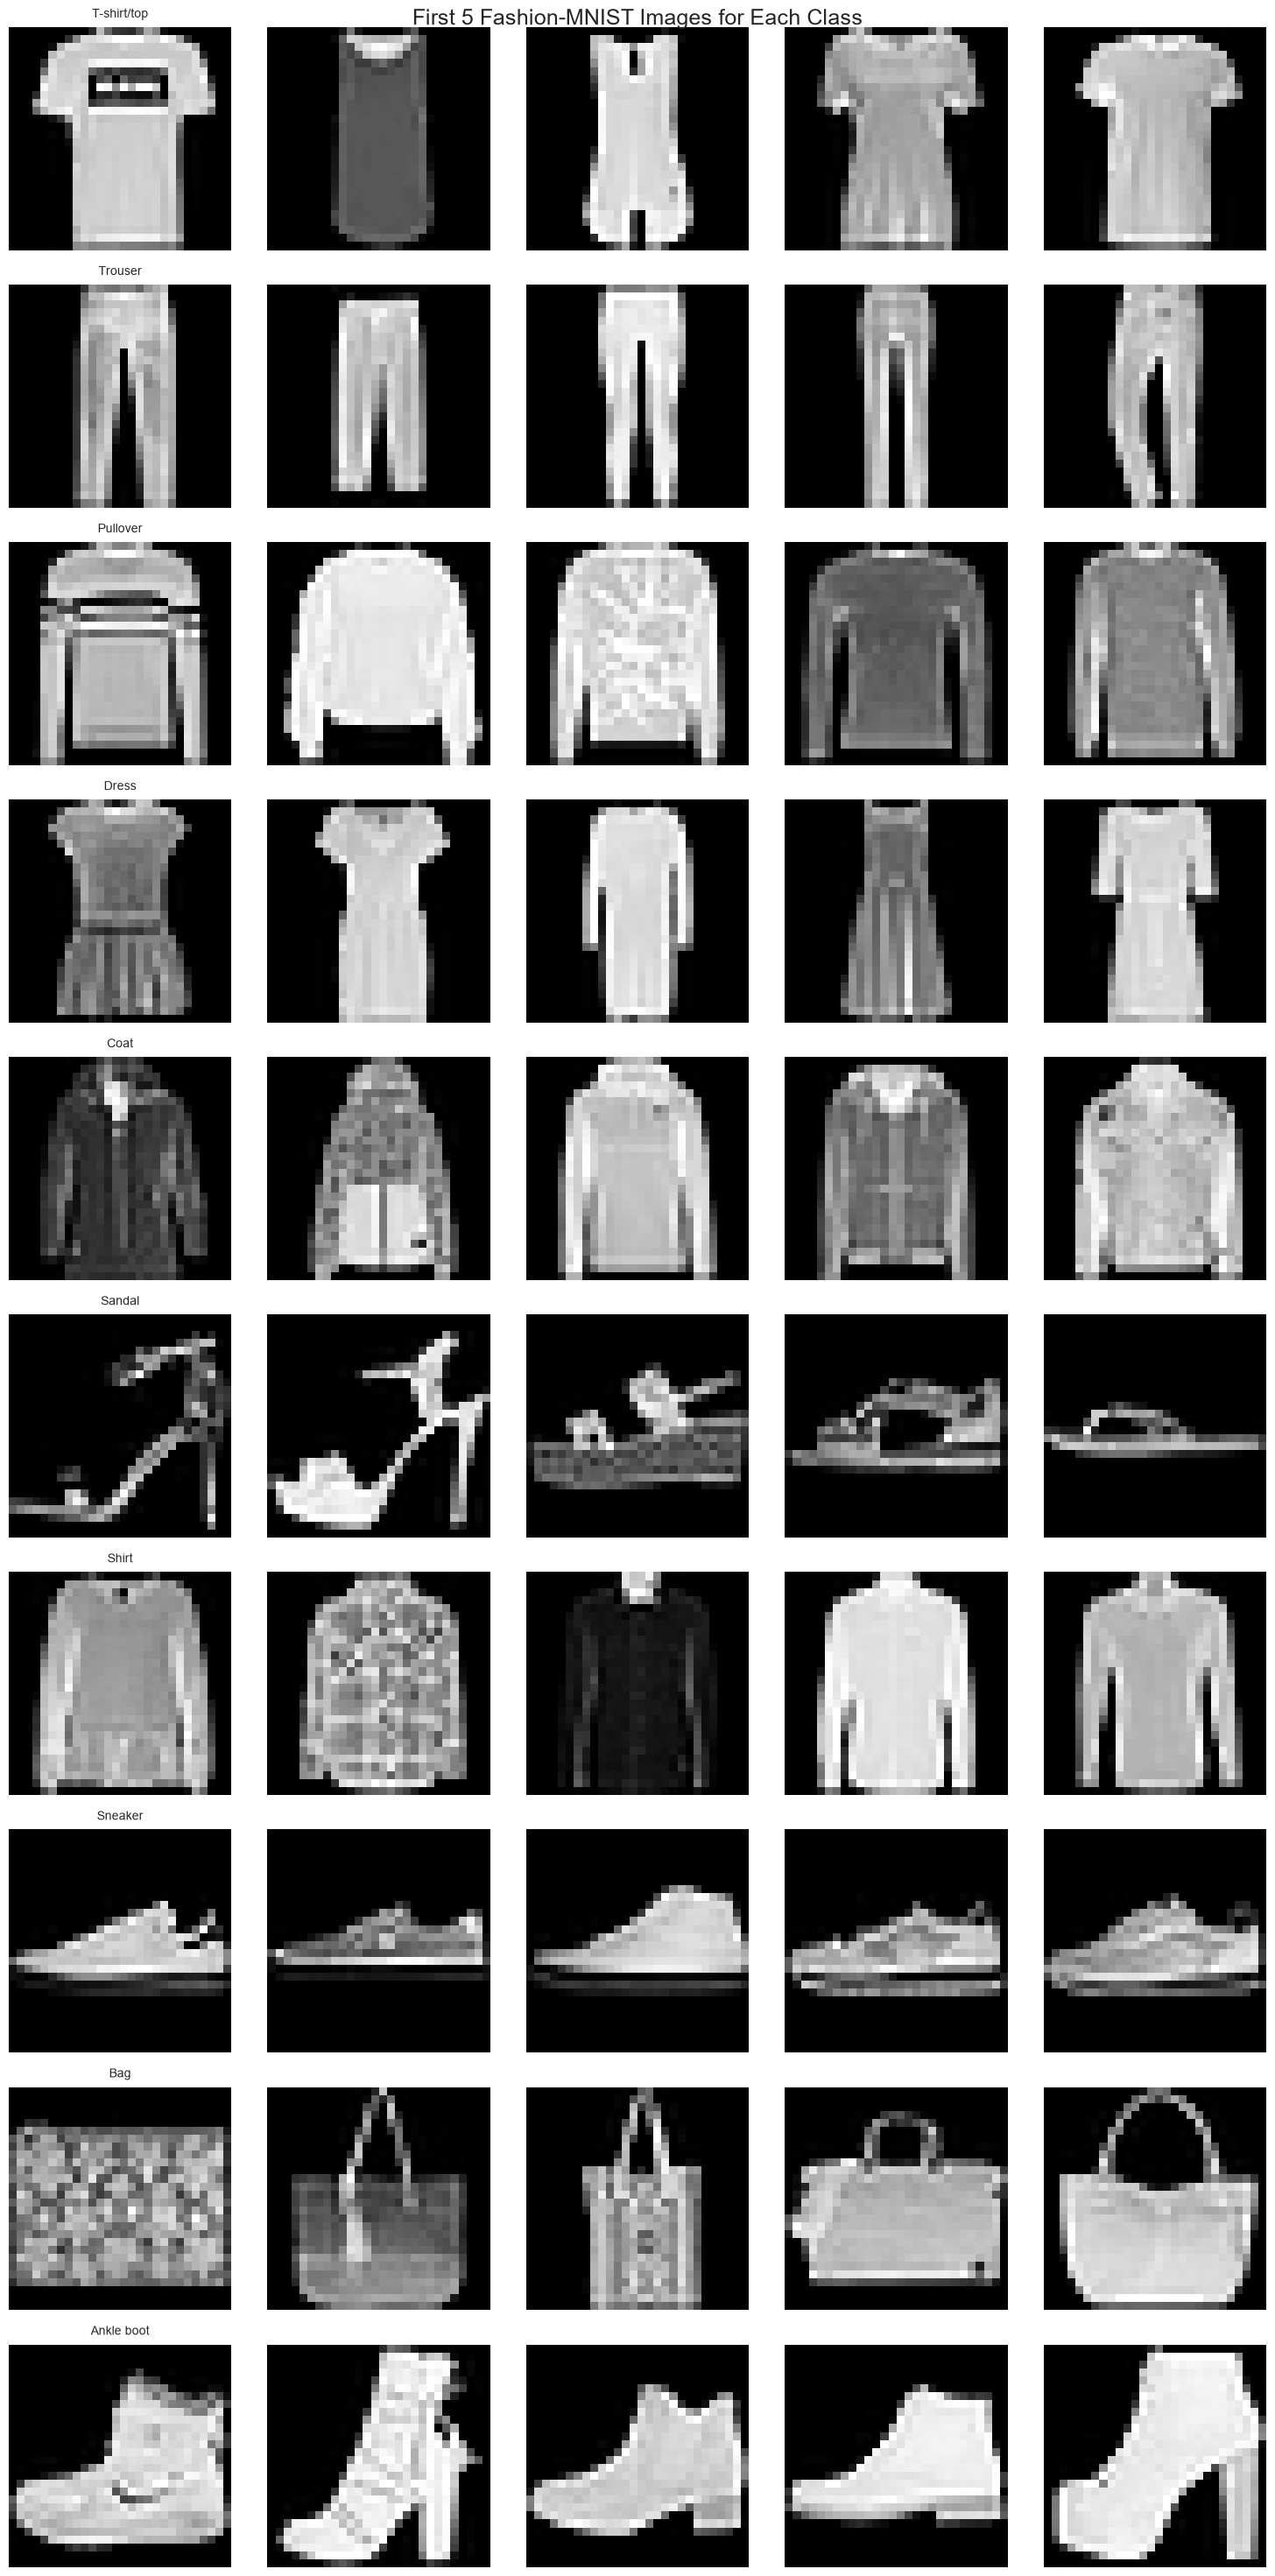

Minimum pixel value in X_train: 0
Maximum pixel value in X_train: 255


In [45]:
# YOUR CODE HERE
# 1. Display the first 5 images in X_train for each class in Y_train, arranged in a 10x5 grid
fig, axes = plt.subplots(10, 5, figsize=(15, 30))
fig.suptitle('First 5 Fashion-MNIST Images for Each Class', fontsize=18)

for class_index, class_name in enumerate(label_names):
    class_indices = np.where(Y_train == class_index)[0][:5]

    for img_index, img_idx in enumerate(class_indices):
        ax = axes[class_index, img_index]
        ax.imshow(X_train[img_idx], cmap='gray')
        ax.axis('off')

    # Put the class label as the title for that row
    axes[class_index, 0].set_title(class_name, fontsize=10, pad=8)

plt.tight_layout()
plt.show()

# 2. Minimum and maximum pixel values in X_train
min_pixel = X_train.min()
max_pixel = X_train.max()

print("Minimum pixel value in X_train:", min_pixel)
print("Maximum pixel value in X_train:", max_pixel)

---
### Step 3: Data preprocessing

This step is essential for preparing this image data in a format that is suitable for ML algorithms. 

### <span style="color:chocolate">Exercise 3:</span> Feature preprocessing (5 points)

In the previous lab, the input data had just a few features. Here, we treat **every pixel value as a separate feature**, so each input example has 28x28 (784) features!

In this exercise, you'll perform the following tasks:

1. Normalize the pixel values in both X_train and X_test data so they range between 0 and 1;
2. For each image in X_train and X_test, flatten the 2-D 28x28 pixel array to a 1-D array of size 784. Hint: use the <span style="color:chocolate">reshape()</span> method available in NumPy. Note that by doing so you will overwrite the original arrays;
3. Pint the shape of X_train and X_test arrays.

In [46]:
# YOUR CODE HERE

# 1. normalize pixel values
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 2. flatten to 1D array
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# 3. print new shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (60000, 784)
X_test shape: (10000, 784)


### <span style="color:chocolate">Exercise 4:</span> Label preprocessing (5 points)

This assignment involves binary classification. Specifically, the objective is to predict whether an image belongs to the sneaker class (class 7) or not.

Therefore, write code so that for each example in (Y_train, Y_test), the outcome variable is represented as follows: 
* $y=1$, for sneaker class (positive examples), and
* $y=0$, for non-sneaker class (negative examples).

Note: To avoid "ValueError: assignment destination is read-only", first create a copy of the (Y_train, Y_test) data and call the resulting arrays (Y_train, Y_test). Then overwrite the (Y_train, Y_test) arrays to create binary outcomes.

In [47]:
# Make copies of the original dataset for binary classification task.
Y_train = np.copy(Y_train)
Y_test = np.copy(Y_test)

# YOUR CODE HERE
# Convert labels to binary: 1 = sneaker, 0 = non-sneaker
Y_train = np.where(Y_train == 7, 1, 0)
Y_test = np.where(Y_test == 7, 1, 0)

# Optional: print a few values to confirm
print("Y_train sample:", Y_train[:10])
print("Y_test sample:", Y_test[:10])

Y_train sample: [0 0 0 0 0 0 1 0 0 0]
Y_test sample: [0 0 0 0 0 0 0 0 0 1]


### <span style="color:chocolate">Exercise 5:</span> Data splits (10 points)

Using the <span style="color:chocolate">train_test_split()</span> method available in scikit-learn:
1. Retain 20% from the training data for validation purposes. Set random state to 1234. All the other arguments of the method are set to default values. Name the resulting dataframes as follows: X_train_mini, X_val, Y_train_mini, Y_val.
2. Print the shape of each array.

In [48]:
# YOUR CODE HERE
# Exercise 5: Data splits
X_train_mini, X_val, Y_train_mini, Y_val = train_test_split(
    X_train,
    Y_train,
    test_size=0.2,
    random_state=1234
)

print("X_train_mini shape:", X_train_mini.shape)
print("X_val shape:", X_val.shape)
print("Y_train_mini shape:", Y_train_mini.shape)
print("Y_val shape:", Y_val.shape)

X_train_mini shape: (48000, 784)
X_val shape: (12000, 784)
Y_train_mini shape: (48000,)
Y_val shape: (12000,)


### <span style="color:chocolate">Exercise 6:</span> Data shuffling (10 points)

Since you'll be using Batch Gradient Descent (BGD) for training, it is important that **each batch is a random sample of the data** so that the gradient computed is representative. 

1. Use integer array indexing to re-order (X_train_mini, Y_train_mini) using a list of shuffled indices. In doing so, you will overwrite the arrays.

In [49]:
np.random.seed(0)
# YOUR CODE HERE
# Create a random permutation of indices
shuffle_idx = np.random.permutation(len(X_train_mini))

# Reorder both arrays in the same way
X_train_mini = X_train_mini[shuffle_idx]
Y_train_mini = Y_train_mini[shuffle_idx]


---
### Step 4: Exploratory Data Analysis (EDA) - cont'd

Before delving into model training, let's further explore the raw feature values by comparing sneaker and non-sneaker training images.

### <span style="color:chocolate">Exercise 7:</span> Pixel distributions (10 points)

1. Identify all sneaker images in X_train_mini and calculate the mean pixel value for each sneaker image. Visualize these pixel values using a histogram. Print the mean pixel value across all sneaker images.
2. Identify all non-sneaker images in X_train_mini and calculate the mean pixel value for each non-sneaker image. Visualize these pixel values using a histogram. Print the mean pixel value across all non-sneaker images.
3. Based on the histogram results, assess whether there is any evidence suggesting that pixel values can be utilized to distinguish between sneaker and non-sneaker images. Justify your response.

Notes: Make sure to provide a descriptive title and axis labels for each histogran. Make sure you utilize Y_train_mini to locate the sneaker and non-sneaker class.

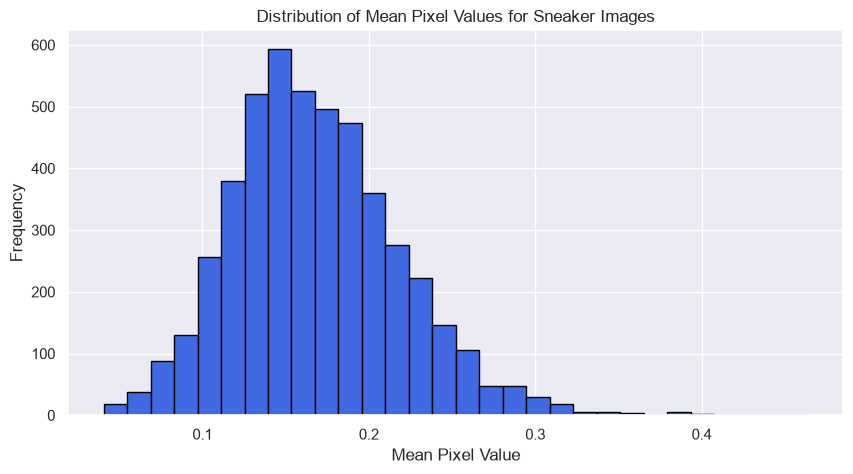

Mean pixel value across all sneaker images: 0.16827475


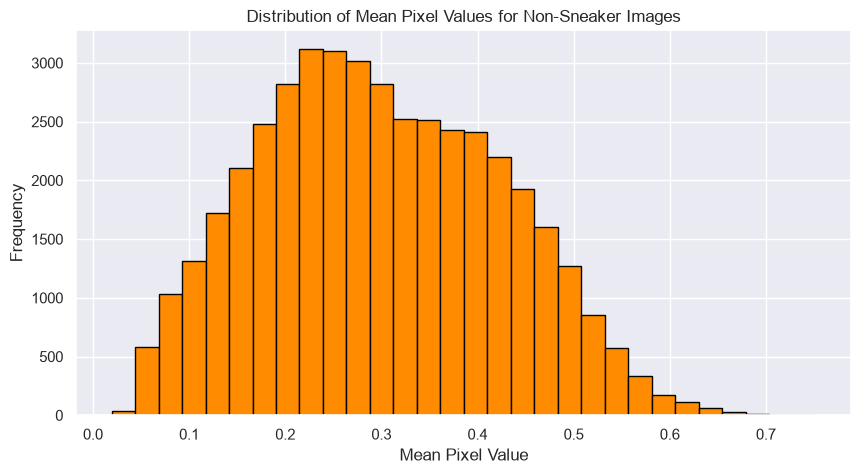

Mean pixel value across all non-sneaker images: 0.29900193


In [50]:
# YOUR CODE HERE

# 1. Sneaker images: mean pixel value per image
sneaker_mask = (Y_train_mini == 1)
sneaker_mean_pixels = X_train_mini[sneaker_mask].mean(axis=1)

plt.figure(figsize=(10, 5))
plt.hist(sneaker_mean_pixels, bins=30, color='royalblue', edgecolor='black')
plt.title('Distribution of Mean Pixel Values for Sneaker Images')
plt.xlabel('Mean Pixel Value')
plt.ylabel('Frequency')
plt.show()

print("Mean pixel value across all sneaker images:", sneaker_mean_pixels.mean())

# 2. Non-sneaker images: mean pixel value per image
non_sneaker_mask = (Y_train_mini == 0)
non_sneaker_mean_pixels = X_train_mini[non_sneaker_mask].mean(axis=1)

plt.figure(figsize=(10, 5))
plt.hist(non_sneaker_mean_pixels, bins=30, color='darkorange', edgecolor='black')
plt.title('Distribution of Mean Pixel Values for Non-Sneaker Images')
plt.xlabel('Mean Pixel Value')
plt.ylabel('Frequency')
plt.show()

print("Mean pixel value across all non-sneaker images:", non_sneaker_mean_pixels.mean())

The non-sneaker images have a higher average pixel value (about 0.299) and a broader brightness distribution than the sneaker images, which average about 0.168 and are concentrated between roughly 0.1 and 0.2. This suggests sneaker images are generally darker and more consistent in brightness. There is some evidence that pixel intensity can help distinguish the two classes, though it is not likely to be a perfect classifier on its own.

---
### Step 4: Modeling

### <span style="color:chocolate">Exercise 8:</span> Baseline model (10 points)

When dealing with classification problems, a simple baseline is to select the *majority* class (the most common label in the training set) and use it as the prediction for all inputs.

With this information in mind:

1. What is the number of sneaker images in Y_train_mini? Print out your answer.
2. What is the number of non-sneaker images in Y_train_mini? Print out your answer.
3. What is the majority class in Y_train_mini? Print out your answer.
4. What is the accuracy of a majority class classifier for Y_train_mini? Print out your answer.
5. Implement a function that computes the Log Loss (binary cross-entropy) metric and use it to evaluate this baseline on both the mini train (Y_train_mini) and validation (Y_val) data. Use 0.1 as the predicted probability for your baseline (reflecting what we know about the original distribution of classes in the mini training data). Hint: for additional help, see the file ``04 Logistic Regression with Tensorflow_helper.ipynb``; You should use **np.log()** when implementing the log loss function.

In [51]:
# YOUR CODE HERE

# 1. Number of sneaker and non-sneaker images
num_sneakers = np.sum(Y_train_mini == 1)
num_non_sneakers = np.sum(Y_train_mini == 0)

print("Number of sneaker images in Y_train_mini:", num_sneakers)
print("Number of non-sneaker images in Y_train_mini:", num_non_sneakers)

# 2. Majority class
if num_sneakers > num_non_sneakers:
    majority_class = 1
else:
    majority_class = 0

print("Majority class in Y_train_mini:", majority_class)

# 3. Accuracy of majority-class classifier
majority_accuracy = np.mean(Y_train_mini == majority_class)
print("Accuracy of majority class classifier on Y_train_mini:", majority_accuracy)

# 4. Log loss function
def log_loss(y_true, p_hat):
    # eps = 1e-12
    # p_hat = np.clip(p_hat, eps, 1 - eps)
    return -np.mean(y_true * np.log(p_hat) + (1 - y_true) * np.log(1 - p_hat))

# 5. Baseline predictions using probability 0.1
p_base = 0.1

train_log_loss = log_loss(Y_train_mini, np.full_like(Y_train_mini, p_base, dtype=float))
val_log_loss = log_loss(Y_val, np.full_like(Y_val, p_base, dtype=float))

print("Baseline log loss on Y_train_mini:", train_log_loss)
print("Baseline log loss on Y_val:", val_log_loss)

Number of sneaker images in Y_train_mini: 4800
Number of non-sneaker images in Y_train_mini: 43200
Majority class in Y_train_mini: 0
Accuracy of majority class classifier on Y_train_mini: 0.9
Baseline log loss on Y_train_mini: 0.3250829733914482
Baseline log loss on Y_val: 0.3250829733914482


### <span style="color:chocolate">Exercise 9:</span> Improvement over Baseline with TensorFlow (10 points)

Let's use TensorFlow to train a binary logistic regression model much like you did in the previous assignment. The goal here is to build a ML model to improve over the baseline classifier.

1. Fill in the <span style="color:green">NotImplemented</span> parts of the build_model() function below by following the instructions provided as comments. Hint: the activation function, the loss, and the evaluation metric are different compared to the linear regression model;
2. Build and compile a model using the build_model() function and the (X_train_mini, Y_train_mini) data. Set learning_rate = 0.0001. Call the resulting object *model_tf*.
3. Train *model_tf* using the (X_train_mini, Y_train_mini) data. Set num_epochs = 5 and batch_size=32. Pass the (X_val, Y_val) data for validation. Hint: see the documentation behind the [tf.keras.Model.fit()](https://www.tensorflow.org/api_docs/python/tf/keras/Model) method.
4. Generate a (1,2) plot (for the mini training and validation data). In the subplot at position (1, 1), display the loss values on the y-axis and the epoch number on the x-axis. In the subplot at position (1, 2), display the accuracy values on the y-axis and the epoch number on the x-axis. Hint: check what the [tf.keras.Model.fit()](https://www.tensorflow.org/api_docs/python/tf/keras/Model) method returns.

In [52]:
def build_model(num_features, learning_rate):
  """Build a TF logistic regression model using Keras.

  Args:
    num_features: The number of input features.
    learning_rate: The desired learning rate for SGD.

  Returns:
    model: A tf.keras model.
  """
  tf.keras.backend.clear_session()
  tf.random.set_seed(0)

  # Build a model using keras.Sequential. While this is intended for neural
  # networks (which may have multiple layers), we want just a single layer for
  # binary logistic regression.
  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Dense(
      units=1,                      # output dim
      input_shape=(num_features,),  # input dim
      use_bias=True,                # use a bias (intercept) param
      activation='sigmoid',         # sigmoid for binary classification
      kernel_initializer=tf.keras.initializers.Ones(),
      bias_initializer=tf.keras.initializers.Ones(),
  ))

  # We need to choose an optimizer. We'll use SGD, which is actually mini-batch GD
  optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

  # Finally, compile the model. Select the accuracy metric (!!!). This finalizes the graph for training.
  model.compile(
      optimizer=optimizer,
      loss='binary_crossentropy',
      metrics=['accuracy']
  )

  return model


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1000 - loss: 205.6167 - val_accuracy: 0.1000 - val_loss: 199.9825
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1000 - loss: 193.0898 - val_accuracy: 0.1000 - val_loss: 187.4252
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1000 - loss: 180.5630 - val_accuracy: 0.1000 - val_loss: 174.8680
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1000 - loss: 168.0361 - val_accuracy: 0.1000 - val_loss: 162.3107
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1000 - loss: 155.5092 - val_accuracy: 0.1000 - val_loss: 149.7533


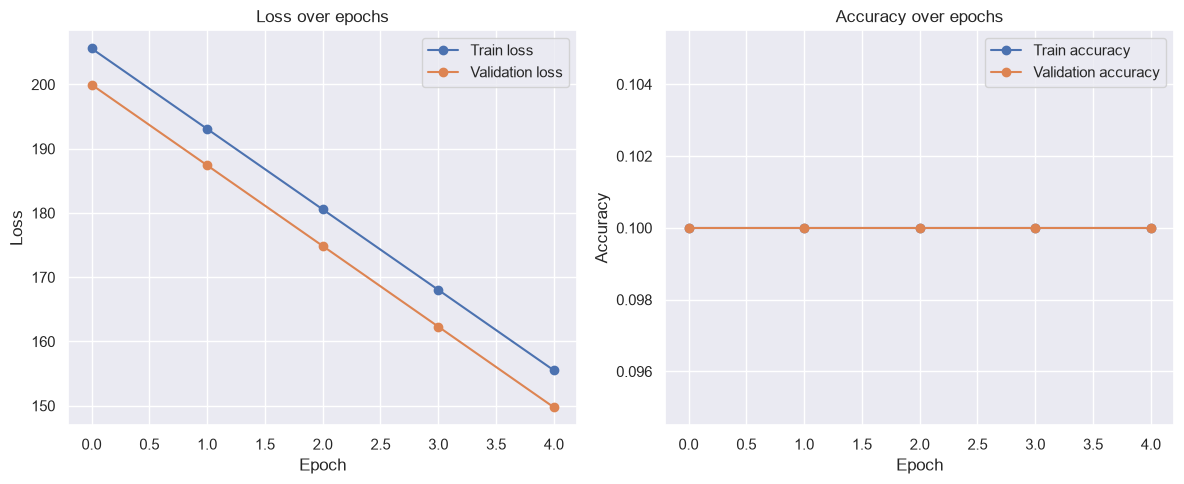

In [53]:
tf.random.set_seed(0)
# 2. Build and compile model
model_tf = build_model(X_train_mini.shape[1], learning_rate=0.0001)

# 3. Fit the model
history = model_tf.fit(
    X_train_mini,
    Y_train_mini,
    epochs=5,
    batch_size=32,
    validation_data=(X_val, Y_val),
    verbose=1
)

# 4. Generate (1,2) plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history.history['loss'], label='Train loss', marker='o')
axes[0].plot(history.history['val_loss'], label='Validation loss', marker='o')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train accuracy', marker='o')
axes[1].plot(history.history['val_accuracy'], label='Validation accuracy', marker='o')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

---
### Step 5: Hyperparameter tuning

Hyperparameter tuning is a crucial step in optimizing ML models. It involves systematically adjusting hyperparameters such as learning rate, number of epochs, and optimizer to find the model configuration that leads to the best generalization performance.

This tuning process is typically conducted by monitoring the model's performance on the validation vs. training set. It's important to note that using the test set for hyperparameter tuning can compromise the integrity of the evaluation process by violating the assumption of "blindness" of the test data.

### <span style="color:chocolate">Exercise 10:</span> Hyperparameter tuning (10 points)

1. Fine-tune the **learning rate** and **number of epochs** hyperparameters of *model_tf* to determine the setup that yields the most optimal generalization performance. Feel free to explore various values for these hyperparameters. Generate a (1, 2) subplot to visualize the training and validation loss on the left, and training and validation accuracy on the right, across all epochs. Hint: you can manually test different hyperparameter values or you can use the [Keras Tuner](https://www.tensorflow.org/tutorials/keras/keras_tuner). If you decide to work with the Keras Tuner, define a new model building function named <span style="color:chocolate">build_model_tuner()</span>.

After identifying your preferred model configuration, print the following information:

2. The first five learned parameters of the model (including the bias term);
3. The final-epoch loss on both the mini training and validation datasets;
4. The difference between the final-epoch training and validation losses;
5. Compare the final-epoch training/validation loss of the TensorFlow model (model_tf) with the baseline model's loss. Does the TensorFlow model demonstrate an improvement over the baseline model?

Please note that we will consider 'optimal model configuration' any last-epoch training and validation loss that is below 0.08.

learning_rate=0.001, epochs=10 -> train_loss=0.6526, val_loss=0.6383
learning_rate=0.001, epochs=20 -> train_loss=0.3833, val_loss=0.3853
learning_rate=0.001, epochs=30 -> train_loss=0.2846, val_loss=0.2899
learning_rate=0.01, epochs=10 -> train_loss=0.1256, val_loss=0.1192
learning_rate=0.01, epochs=20 -> train_loss=0.0793, val_loss=0.0754
learning_rate=0.01, epochs=30 -> train_loss=0.0644, val_loss=0.0619
learning_rate=0.1, epochs=10 -> train_loss=0.0491, val_loss=0.0489
learning_rate=0.1, epochs=20 -> train_loss=0.0453, val_loss=0.0472
learning_rate=0.1, epochs=30 -> train_loss=0.0437, val_loss=0.0468

Best combination found:
learning_rate = 0.1
epochs = 30
final train loss = 0.04372114688158035
final validation loss = 0.04679723456501961


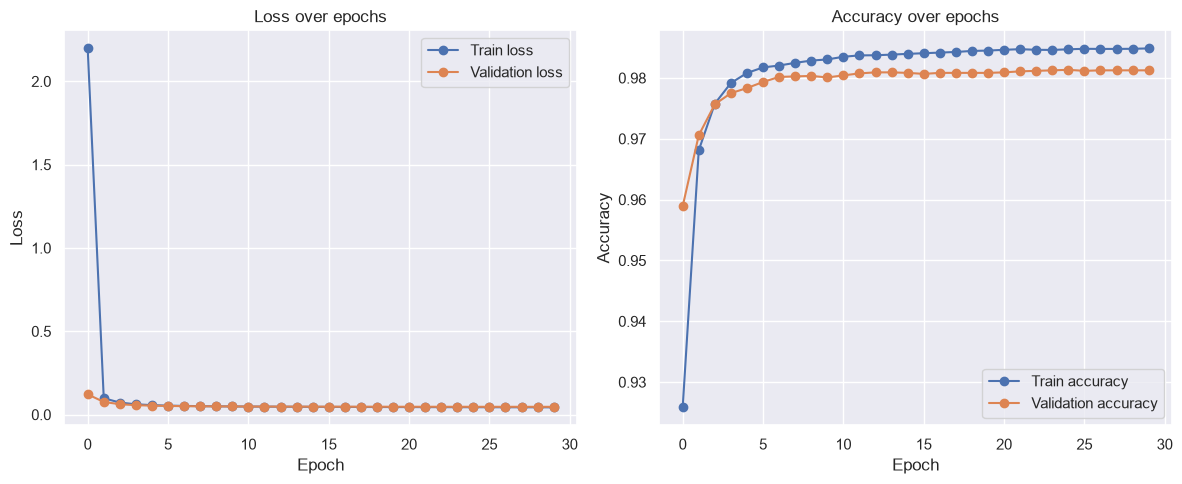


First five learned parameters (including bias): [ 0.99974287  0.9986878   0.9743068   0.95396966 -1.976846  ]
Final-epoch loss on mini training: 0.04372114688158035
Final-epoch loss on validation: 0.04679723456501961
Difference between final train and validation losses: -0.0030760876834392548
Baseline log loss: 0.3250829733914482
Best TF validation loss: 0.04679723456501961


In [54]:
# YOUR CODE HERE
learning_rates = [ 0.01, .1]
num_epochs_list = [10, 20, 30]

best_result = {
    "learning_rate": None,
    "epochs": None,
    "train_loss": float("inf"),
    "val_loss": float("inf"),
    "history": None,
    "model": None
}

for learning_rate in learning_rates:
    for num_epochs in num_epochs_list:
        tf.keras.backend.clear_session()

        model = build_model(X_train_mini.shape[1], learning_rate=learning_rate)

        history = model.fit(
            X_train_mini,
            Y_train_mini,
            epochs=num_epochs,
            batch_size=32,
            validation_data=(X_val, Y_val),
            verbose=0
        )

        final_train_loss = history.history["loss"][-1]
        final_val_loss = history.history["val_loss"][-1]

        print(
            f"learning_rate={learning_rate}, epochs={num_epochs} "
            f"-> train_loss={final_train_loss:.4f}, val_loss={final_val_loss:.4f}"
        )

        if final_val_loss < best_result["val_loss"]:
            best_result["learning_rate"] = learning_rate
            best_result["epochs"] = num_epochs
            best_result["train_loss"] = final_train_loss
            best_result["val_loss"] = final_val_loss
            best_result["history"] = history
            best_result["model"] = model

print("\nBest combination found:")
print("learning_rate =", best_result["learning_rate"])
print("epochs =", best_result["epochs"])
print("final train loss =", best_result["train_loss"])
print("final validation loss =", best_result["val_loss"])

# Plot the best model's learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(best_result["history"].history["loss"], label="Train loss", marker="o")
axes[0].plot(best_result["history"].history["val_loss"], label="Validation loss", marker="o")
axes[0].set_title("Loss over epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(best_result["history"].history["accuracy"], label="Train accuracy", marker="o")
axes[1].plot(best_result["history"].history["val_accuracy"], label="Validation accuracy", marker="o")
axes[1].set_title("Accuracy over epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

# 2. First five learned parameters of the model (including the bias term)
weights = best_result["model"].layers[0].get_weights()
kernel = weights[0].ravel()
bias = weights[1]

first_five_params = np.concatenate([kernel[:4], bias.reshape(1)])
print("\nFirst five learned parameters (including bias):", first_five_params)

# 3. Final-epoch loss on both mini training and validation
final_train_loss = best_result["history"].history["loss"][-1]
final_val_loss = best_result["history"].history["val_loss"][-1]

print("Final-epoch loss on mini training:", final_train_loss)
print("Final-epoch loss on validation:", final_val_loss)

# 4. Difference between final train and validation losses
loss_difference = final_train_loss - final_val_loss
print("Difference between final train and validation losses:", loss_difference)

# 5. Compare with the baseline model
baseline_val_loss = val_log_loss
print("Baseline log loss:", baseline_val_loss)
print("Best TF validation loss:", final_val_loss)


Yes, the TF model demonstrates a significant improvement over the baseline model of just marking everything as not a sneaker.

---
### Step 6: Evaluation and Generalization


Now that you've determined the optimal set of hyperparameters, it's time to evaluate your optimized model on the test data to gauge its performance in real-world scenarios, commonly known as inference.

### <span style="color:chocolate">Exercise 11:</span> Computing accuracy (10 points)

1. Calculate aggregate accuracy on both mini train and test datasets using a probability threshold of 0.5. Hint: You can utilize the <span style="color:chocolate">model.evaluate()</span> method provided by tf.keras. Note: Aggregate accuracy measures the overall correctness of the model across all classes in the dataset;

2. Does the model demonstrate strong aggregate generalization capabilities? Provide an explanation based on your accuracy observations for training vs. test datasets.

In [63]:
# Use the best model selected from the hyperparameter search.
opt_model = best_result["model"]

train_acc = opt_model.evaluate(X_train_mini, Y_train_mini, verbose=0)[1]
test_acc = opt_model.evaluate(X_test, Y_test, verbose=0)[1]


print("Aggregate accuracy on mini train:", train_acc)
print("Aggregate accuracy on test:", test_acc)


Aggregate accuracy on mini train: 0.9851250052452087
Aggregate accuracy on test: 0.9815000295639038


The model demonstrates strong generalization capabilities as we see that the train and test accuracy is essentially the exact same, at ~98%. 

### <span style="color:chocolate">Exercise 12:</span> (10 points)

1. Generate and visualize the confusion matrix on the test dataset using a probability threshold of 0.5. Additionally, print the True Positives (TP), False Negatives (FN), False Positives (FP), and True Negatives (TN). Hint: you can utilize the <span style="color:chocolate">model.predict()</span> method available in tf.keras, and then the <span style="color:chocolate">confusion_matrix()</span>, <span style="color:chocolate">ConfusionMatrixDisplay()</span> methods available in sklearn.metrics;

2. Compute subgroup accuracy, separately for the sneaker and non-sneaker classes, on the test dataset using a probability threshold of 0.5. Reflect on any observed accuracy differences (potential lack of fairness) between the two classes.

3. Does the model demonstrate strong subgroup generalization capabilities? Provide an explanation based on your accuracy observations. Hint: compare training vs. test accuracy.

Confusion matrix:
 [[8902   98]
 [  87  913]]


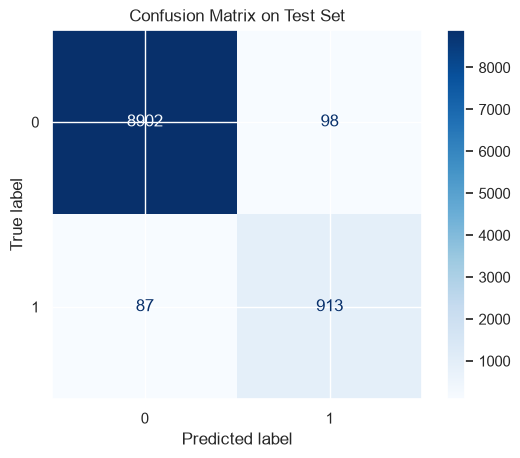

True Positives (TP): 913
False Negatives (FN): 87
False Positives (FP): 98
True Negatives (TN): 8902
Subgroup accuracy for sneaker class: 0.913
Subgroup accuracy for non-sneaker class: 0.9891111111111112
Training subgroup accuracy for sneaker class: 0.9160416666666666
Training subgroup accuracy for non-sneaker class: 0.992800925925926


In [ ]:
# Use the optimized model and a decision threshold of 0.5.
opt_model = best_result["model"]

probs_test = opt_model.predict(X_test, verbose=0).ravel()
preds_test = (probs_test >= 0.5).astype(int)

cm = confusion_matrix(Y_test, preds_test)
print("Confusion matrix:\n", cm)

cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
cm_display.plot(cmap='Blues')
plt.title('Confusion Matrix on Test Set')
plt.show()

TN, FP = cm[0]
FN, TP = cm[1]

print("True Positives (TP):", TP)
print("False Negatives (FN):", FN)
print("False Positives (FP):", FP)
print("True Negatives (TN):", TN)

sneaker_mask = (Y_test == 1)
non_sneaker_mask = (Y_test == 0)

sneaker_accuracy = np.mean(preds_test[sneaker_mask] == Y_test[sneaker_mask])
non_sneaker_accuracy = np.mean(preds_test[non_sneaker_mask] == Y_test[non_sneaker_mask])

print("Subgroup accuracy for sneaker class:", sneaker_accuracy)
print("Subgroup accuracy for non-sneaker class:", non_sneaker_accuracy)

probs_train = opt_model.predict(X_train_mini, verbose=0).ravel()
preds_train = (probs_train >= 0.5).astype(int)


train_sneaker_acc = np.mean(preds_train[Y_train_mini == 1] == Y_train_mini[Y_train_mini == 1])
print("Training subgroup accuracy for sneaker class:", train_sneaker_acc)


train_non_sneaker_acc = np.mean(preds_train[Y_train_mini == 0] == Y_train_mini[Y_train_mini == 0])
print("Training subgroup accuracy for non-sneaker class:", train_non_sneaker_acc)


test_sneaker_acc 

The subgroup accuracy is higher for the non-sneaker class at 99% vs. 91% for the sneaker class. This indicates that the model is worse at predicting that an image is a sneaker vs. at predicting that an image is not a sneaker, presumably due to the higher concentration of non-sneakers in the dataset.

Train vs. test subgroup accuracy is approximately the same, so the model displays powerful subgroup generalization.



----
### <span style="color:chocolate"></span> Additional practice (not graded)